In [1]:
import os
import torch
import numpy as np, pandas as pd, random
import matplotlib.pyplot as plt, seaborn as sns
from tqdm.notebook import tqdm
from time import time, sleep
import itertools

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import balanced_accuracy_score, log_loss
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import KBinsDiscretizer, TargetEncoder, LabelEncoder

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [2]:
## -- Global Settings --
# sklearn.set_config(transform_output="pandas")

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use("ggplot")

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Configuration --
CFG = {
    'FOLDS': 5,
    'SEED': 42,
    'GREEN': '\033[32m',
    'YELLOW': '\033[33m',
    'RESET': '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [3]:
# def seed_everything(seed):
#     os.environ['PYTHONHASHSEED'] = str(seed)
#     random.seed(seed)
#     np.random.seed(seed)
#     # torch.manual_seed(seed)
#     # torch.cuda.manual_seed_all(seed)
#     # torch.backends.cudnn.benchmark = False
#     # torch.backends.cudnn.deterministic = True

# seed_everything(seed=CFG['SEED'])

## Load Data

In [4]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = 'kaggle' # -> 'colab' 'kaggle'

if PLATFORM == 'kaggle':
    PATH = '/kaggle/input/competitions/playground-series-s6e6/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+"train.csv")
    test = pd.read_csv(PATH+"test.csv")

    ORIG_PATH = '/kaggle/input/datasets/fedesoriano/stellar-classification-dataset-sdss17/'
    orig = pd.read_csv(ORIG_PATH+'star_classification.csv')#.drop(['customerID'], axis=1)
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = '/content/drive/MyDrive/-- shared_notebooks --/Ps6e6 | Stellar Class/_stellar_data/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')
    orig = pd.read_csv(PATH+'star_classification.csv')#.drop(['customerID'], axis=1)

## =================================================================================

ID = 'id'
TARGET = train.columns[-1]

CATS   = ['spectral_type', 'galaxy_population']
NUMS   = [c for c in train.columns if c not in CATS+[TARGET, 'id']]
BASE   = NUMS + CATS

mapping = {c: i for i, c in enumerate(train[TARGET].unique())}
r_mapping = {i: c for i, c in enumerate(train[TARGET].unique())}

for df in [train, orig]:
    df[TARGET] = df[TARGET].map(mapping)

for (name, df) in [('Train', train), ('Test', test), ('Original', orig)]:
    print(f"{name} shape: {df.shape}")

print(f"\nTotal nums: {len(NUMS)}")
print(f"Total cats: {len(CATS)}")
print(f"Total base: {len(BASE)}")

Train shape: (577347, 12)
Test shape: (247435, 11)
Original shape: (100000, 18)

Total nums: 8
Total cats: 2
Total base: 10


In [5]:
## -- ['spectral_type', 'galaxy_population'] derivation for original data --
def spectral_type(g, r):
    return pd.cut(
        r-g, 
        [-np.inf, -1, -0.5, 0, np.inf],
        labels=['M', 'G/K', 'A/F', 'O/B']
    ).astype(str)

def galaxy_population(u, r):
    return pd.cut(
        u-r, 
        [-np.inf, 2.2, np.inf],
        labels=['Blue_Cloud', 'Red_Sequence']
    ).astype(str)

orig['spectral_type'] = spectral_type(orig['g'], orig['r'])
orig['galaxy_population'] = galaxy_population(orig['u'], orig['r'])

orig.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID,spectral_type,galaxy_population
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,0,0.634794,5812,56354,171,M,Red_Sequence
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,0,0.779136,10445,58158,427,A/F,Blue_Cloud
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,0,0.644195,4576,55592,299,M,Red_Sequence
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,0,0.932346,9149,58039,775,M,Blue_Cloud
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,0,0.116123,6121,56187,842,M,Red_Sequence


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 577347 non-null  int64  
 1   alpha              577347 non-null  float64
 2   delta              577347 non-null  float64
 3   u                  577347 non-null  float64
 4   g                  577347 non-null  float64
 5   r                  577347 non-null  float64
 6   i                  577347 non-null  float64
 7   z                  577347 non-null  float64
 8   redshift           577347 non-null  float64
 9   spectral_type      577347 non-null  object 
 10  galaxy_population  577347 non-null  object 
 11  class              577347 non-null  int64  
dtypes: float64(8), int64(2), object(2)
memory usage: 52.9+ MB


In [7]:
def get_class_weights(y):
    """
    y: Current y labels -> numpy array or series
    """
    cls_ = np.unique(y)
    wts_ = compute_class_weight("balanced", classes=cls_, y=y)
    return dict(zip(cls_, wts_))

def get_sample_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> label: weight
    """
    if opt != 'auto':
        return np.array([opt[label] for label in y])
    else:
        cls_ = np.unique(y_true)
        wts_ = compute_class_weight("balanced", classes=cls_, y=y_true)
        cls_wts = dict(zip(cls_, wts_))
        return np.array([cls_wts[label] for label in y])

def balanced_acc(y_true, y_proba):
    pred_labels = np.argmax(y_proba, axis=1)
    return balanced_accuracy_score(y_true, pred_labels)

def multi_class_brier(y_true, y_proba, classes):
    y_onehot = label_binarize(y_true, classes=classes)
    return float(np.mean(np.sum((y_onehot - y_proba) ** 2, axis=1)))

def t_enc_multi(X_tr, X_va, X_ts, y_tr, cols, drop=False):
    X_tr_1 = X_tr.copy()
    X_va_1 = X_va.copy()
    X_ts_1 = X_ts.copy()

    te_enc = TargetEncoder(target_type="multiclass", random_state=CFG["SEED"]).set_output(transform="pandas")

    X_tr_te = te_enc.fit_transform(X_tr_1[cols], y_tr)
    X_va_te = te_enc.transform(X_va_1[cols])
    X_ts_te = te_enc.transform(X_ts_1[cols])

    te_names = [f"TE_{c}" for c in X_tr_te.columns]
    X_tr_1[te_names] = X_tr_te
    X_va_1[te_names] = X_va_te
    X_ts_1[te_names] = X_ts_te

    if drop:
        X_tr_1 = X_tr_1.drop(columns=cols)
        X_va_1 = X_va_1.drop(columns=cols)
        X_ts_1 = X_ts_1.drop(columns=cols)

    return X_tr_1, X_va_1, X_ts_1

print("- Helper functions ready -")

- Helper functions ready -


## Preprocess Features

In [8]:
## -- FE by @chris

X = train.drop(columns=[ID, TARGET]); train_id = train[ID]
y = train[TARGET]
X_ts = test.drop(columns=[ID]); test_id = test[ID]

del train, test
print("X      init shape:", X.shape)
print("X_ts init shape:", X_ts.shape, "\n")

base_cat_cols = X.select_dtypes(include=['object']).columns.tolist()
base_num_cols = X.select_dtypes(exclude=['object']).columns.tolist()
print('Base categorical columns:', base_cat_cols)
print('Base numeric columns:', base_num_cols)

cat_cols = base_cat_cols.copy()
num_cols = base_num_cols.copy()

category_map = {}
## -- u-g, g-r, r-i, i-z, u-r, g-i, and r-z
color_pairs = [
    ('u', 'g'),
    ('g', 'r'),
    ('r', 'i'),
    ('i', 'z'),
    ('u', 'r'),
    ('g', 'i'),
    ('r', 'z'),
]
important_combos = [
    ('alpha_cat_', 'delta_cat_'),
    ('u_cat_', 'z_cat_'),
]

def feature_engineering(df, fit=False):
    df = df.copy()

    # Smooth numeric/color-locus features.
    df['_g_div_redshift'] = (df['g'] / (df['redshift'] + 1e-6)).replace([np.inf, -np.inf], np.nan).fillna(0).astype('float32')
    df['_i_div_redshift'] = (df['i'] / (df['redshift'] + 1e-6)).replace([np.inf, -np.inf], np.nan).fillna(0).astype('float32')
    for a, b in color_pairs:
        df[f'_{a}-{b}'] = (df[a] - df[b]).astype('float32')

    mags = df[['u', 'g', 'r', 'i', 'z']].astype('float32')
    df['_mag_mean'] = mags.mean(axis=1).astype('float32')
    df['_mag_range'] = (mags.max(axis=1) - mags.min(axis=1)).astype('float32')

    shifted_redshift = df['redshift'].astype('float32') - min(0.0, float(df['redshift'].min())) + 1e-4
    df['_log1p_redshift'] = np.log1p(shifted_redshift).astype('float32')

    # Original categorical columns.
    for col in base_cat_cols:
        if fit:
            codes, uniques = pd.factorize(df[col], sort=False)
            category_map[col] = uniques
        else:
            uniques = category_map[col]
            code_map = {cat: i for i, cat in enumerate(uniques)}
            codes = df[col].map(code_map).fillna(-1).astype('int32')
        df[col] = pd.Series(codes, index=df.index).astype('int32').astype('category')

    # Integer-floor categorical views of every base numeric feature.
    for col in base_num_cols:
        cat_name = f'{col}_cat_'
        floored = np.floor(df[col]).astype('float32')
        if fit:
            codes, uniques = pd.factorize(floored, sort=False)
            category_map[cat_name] = uniques
        else:
            uniques = category_map[cat_name]
            code_map = {cat: i for i, cat in enumerate(uniques)}
            codes = floored.map(code_map).fillna(-1).astype('int32')
        df[cat_name] = pd.Series(codes, index=df.index).astype('int32').astype('category')

    # Delta quantile bins from the best local run.
    for n_bins in [100, 500]:
        bin_name = f'delta_{n_bins}_quantile_bin_'
        if fit:
            kb = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile', subsample=None)
            binned = kb.fit_transform(df[['delta']]).ravel().astype('int32')
            category_map[bin_name] = kb
        else:
            kb = category_map[bin_name]
            binned = kb.transform(df[['delta']]).ravel().astype('int32')
        df[bin_name] = pd.Series(binned, index=df.index).astype('int32').astype('category')

    # Interaction categories used only for fold-safe multiclass target encoding.
    combo_names = []
    for cols in important_combos:
        combo_name = '__'.join(cols) + '__'
        combo_names.append(combo_name)
        combo = df[cols[0]].astype(str)
        for col in cols[1:]:
            combo = combo + '|' + df[col].astype(str)
        if fit:
            codes, uniques = pd.factorize(combo, sort=False)
            category_map[combo_name] = uniques
        else:
            uniques = category_map[combo_name]
            code_map = {cat: i for i, cat in enumerate(uniques)}
            codes = combo.map(code_map).fillna(-1).astype('int32')
        df[combo_name] = pd.Series(codes, index=df.index).astype('int32').astype('category')

    new_cat_cols = [c for c in df.columns if str(df[c].dtype) == 'category' and c not in base_cat_cols]
    new_num_cols = [c for c in df.columns if c.startswith('_') and str(df[c].dtype) != 'category']
    return df, new_cat_cols, new_num_cols, combo_names

X, new_cat_cols, new_num_cols, combo_names = feature_engineering(X, fit=True)
X_ts, new_cat_cols, new_num_cols, combo_names = feature_engineering(X_ts, fit=False)
cat_cols += new_cat_cols; num_cols += new_num_cols
print("len(new_cat_cols):", len(new_cat_cols))
print("len(new_num_cols):", len(new_num_cols), "\n")

cat_cols = sorted(cat_cols)
X = X.reindex(sorted(X.columns), axis=1)
X_ts = X_ts.reindex(sorted(X_ts.columns), axis=1)
print("prep len(cat_cols):", len(cat_cols))
print("prep len(num_cols):", len(num_cols), "\n")
print("X      prep shape:", X.shape)
print("X_test prep shape:", X_ts.shape, "\n")

X      init shape: (577347, 10)
X_ts init shape: (247435, 10) 

Base categorical columns: ['spectral_type', 'galaxy_population']
Base numeric columns: ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
len(new_cat_cols): 12
len(new_num_cols): 12 

prep len(cat_cols): 14
prep len(num_cols): 20 

X      prep shape: (577347, 34)
X_test prep shape: (247435, 34) 



In [9]:
# ## -- FE by @yekenot

# X = train.drop(columns=[ID, TARGET]); train_id = train[ID]
# y = train[TARGET]
# X_ts = test.drop(columns=[ID]); test_id = test[ID]

# del train, test
# print("X      init shape:", X.shape)
# print("X_ts init shape:", X_ts.shape, "\n")

# cat_cols = X.select_dtypes(include=['object']).columns.tolist()
# num_cols = X.select_dtypes(exclude=['object']).columns.tolist()
# print("init len(cat_cols):", len(cat_cols))
# print("init len(num_cols):", len(num_cols), "\n")

# category_map = {}

# color_pairs = [
#     ('u', 'g'),
#     ('g', 'r'),
#     ('i', 'z'),
#     ('r', 'z'),
#     ('u', 'z'),
# ]

# important_combos = [
#     ('alpha_cat_', 'delta_cat_'),
#     ('u_cat_', 'z_cat_'),
# ]
# important_combos = sorted(important_combos)

# def feature_engineering(df, fit=False):
#     # Arithmetic interaction
#     df['_log_redshift'] = np.log1p(df['redshift']).astype('float32')
#     df['_g_/_redshift'] = (df['g'] / (df['redshift'] + 1e-6)).astype('float32')
#     df['_i_/_redshift'] = (df['i'] / (df['redshift'] + 1e-6)).astype('float32')
#     for a, b in color_pairs:
#         df[f"_{a}-{b}"] = (df[a] - df[b]).astype('float32')

#     # Categorize string cats
#     for col in cat_cols:
#         if fit:
#             codes, uniques = df[col].factorize()
#             category_map[col] = uniques
#         else:
#             uniques = category_map[col]
#             code_map = {cat: i for i, cat in enumerate(uniques)}
#             codes = df[col].map(code_map).fillna(-1).astype('int32')
#         df[col] = codes
#         df[col] = df[col].astype('category')

#     # Categorize numericals
#     for col in num_cols:
#         cat_name = f"{col}_cat_"
#         if fit:
#             codes, uniques = np.floor(df[col]).factorize()
#             category_map[col] = uniques
#         else:
#             uniques = category_map[col]
#             code_map = {cat: i for i, cat in enumerate(uniques)}
#             codes = np.floor(df[col]).map(code_map).fillna(-1).astype('int32')
#         df[cat_name] = codes
#         df[cat_name] = df[cat_name].astype('category')

#     # Discretize numericals
#     bin_config = {'delta': [100, 500]}
#     for col, bins_list in bin_config.items():
#         for n_bins in bins_list:
#             for strategy in ['quantile']:
#                 bin_name = f"{col}_{n_bins}_{strategy}_bin_"
#                 if fit:
#                     kb = KBinsDiscretizer(
#                         n_bins=n_bins,
#                         encode='ordinal',
#                         strategy=strategy,
#                         subsample=None
#                     )
#                     binned = kb.fit_transform(df[[col]]).ravel().astype('int32')
#                     category_map[bin_name] = kb
#                 else:
#                     kb = category_map[bin_name]
#                     binned = kb.transform(df[[col]]).ravel().astype('int32')
#                 df[bin_name] = binned
#                 df[bin_name] = df[bin_name].astype('category')

#     # Create interaction categories
#     combo_names = []
#     for cols in important_combos:
#         combo_name = '_'.join(cols) + '_'
#         combo_names.append(combo_name)
#         combo_series = df[cols[0]].astype(str)
#         for col in cols[1:]:
#             combo_series = combo_series + '_' + df[col].astype(str)
#         if fit:
#             codes, uniques = pd.factorize(combo_series, sort=False)
#             category_map[combo_name] = uniques
#         else:
#             uniques = category_map[combo_name]
#             code_map = {cat: i for i, cat in enumerate(uniques)}
#             codes = combo_series.map(code_map).fillna(-1).astype('int32')
#         df[combo_name] = codes
#         df[combo_name] = df[combo_name].astype('category')

#     new_cat_cols = [col for col in df.columns if col.endswith('_')]
#     new_num_cols = [col for col in df.columns if col.startswith('_')]
#     return df, new_cat_cols, new_num_cols, combo_names

# X, new_cat_cols, new_num_cols, combo_names = feature_engineering(X, fit=True)
# X_ts, new_cat_cols, new_num_cols, combo_names = feature_engineering(X_ts, fit=False)
# cat_cols += new_cat_cols; num_cols += new_num_cols
# print("len(new_cat_cols):", len(new_cat_cols))
# print("len(new_num_cols):", len(new_num_cols), "\n")

# cat_cols = sorted(cat_cols)
# X = X.reindex(sorted(X.columns), axis=1)
# X_ts = X_ts.reindex(sorted(X_ts.columns), axis=1)
# print("prep len(cat_cols):", len(cat_cols))
# print("prep len(num_cols):", len(num_cols), "\n")
# print("X      prep shape:", X.shape)
# print("X_test prep shape:", X_ts.shape, "\n")

In [10]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
    ):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"oTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [11]:
# X, X_ts, _, ORIG_COLS = orig_TE_data_propagate(
#     orig,
#     X,
#     X_ts,
#     X.iloc[:500],
#     features=NUMS+['Contract', 'InternetService', 'PaymentMethod'], # 
#     target=TARGET,
#     aggs=['mean'], # mean, median, count, std, skew, nunique, max, min
#     fill_nan=True,
# )

In [12]:
X

,_g-i,_g-r,_g_div_redshift,_i-z,_i_div_redshift,_log1p_redshift,_mag_mean,_mag_range,_r-i,_r-z,_u-g,_u-r,alpha,alpha_cat_,alpha_cat___delta_cat___,delta,delta_100_quantile_bin_,delta_500_quantile_bin_,delta_cat_,g,g_cat_,galaxy_population,i,i_cat_,r,r_cat_,redshift,redshift_cat_,spectral_type,u,u_cat_,u_cat___z_cat___,z,z_cat_
0,2.638446,1.537632,53.536564,0.636056,47.085331,0.349989,21.120754,6.851065,1.100813,1.736869,3.576564,5.114196,147.734256,0,0,16.959273,43,215,0,21.895559,0,0,19.257113,0,20.357926,0,0.408982,0,0,25.472123,0,0,18.621057,0
1,1.860995,1.499854,120.821922,0.439634,109.041748,0.155332,18.293056,3.992077,0.361141,0.800775,1.691447,3.191300,127.988677,1,1,32.346716,66,331,1,19.087062,1,0,17.226067,1,17.587208,1,0.157976,0,0,20.778509,1,1,16.786433,1
2,0.496499,-0.092712,7.464886,0.025263,7.289058,1.343867,20.885235,0.614475,0.589211,0.614474,-0.043925,-0.136637,179.792648,2,2,35.344843,71,358,2,21.079128,0,1,20.582629,2,21.171840,2,2.823770,1,1,21.035203,2,2,20.557366,2
3,2.685077,2.032982,39.266460,0.450706,34.257919,0.435780,19.930828,5.390104,0.652096,1.102802,2.254320,4.287302,225.818295,3,3,48.569421,91,457,3,21.050736,0,0,18.365658,3,19.017754,3,0.536099,0,0,23.305056,3,3,17.914952,3
4,1.572233,1.237231,35.035980,0.283262,32.207016,0.448417,18.984982,4.086973,0.335002,0.618264,2.231478,3.468709,141.836135,4,4,19.342852,46,233,4,19.471680,1,0,17.899447,1,18.234449,4,0.555761,0,0,21.703158,2,4,17.616185,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
577342,1.663665,1.151093,36.858784,0.639180,33.606422,0.419759,18.225586,4.277374,0.512572,1.151752,1.974528,3.125621,223.539288,25,4081,2.503680,25,125,8,18.854201,5,0,17.190536,1,17.703108,1,0.511524,0,0,20.828729,1,1,16.551356,1
577343,3.178909,1.661308,33.950043,0.232989,29.123203,0.512021,20.983864,4.787468,1.517602,1.750591,1.375570,3.036877,223.895970,25,584,40.769343,80,400,48,22.359173,2,0,19.180264,0,20.697865,0,0.658589,0,0,23.734743,3,23,18.947275,0
577344,2.443580,2.189890,56.373665,0.568879,49.880714,0.326720,19.832348,3.740854,0.253691,0.822570,0.728394,2.918283,52.258927,265,1819,0.671887,19,98,34,21.215856,0,0,18.772276,3,19.025966,3,0.376342,0,0,21.944250,2,26,18.203397,0
577345,0.691842,0.635191,7.538373,-0.547210,7.297174,1.355430,21.397856,1.038958,0.056651,-0.490559,0.347115,0.982306,247.362248,267,2109,50.659819,93,467,46,21.622766,0,1,20.930924,2,20.987575,0,2.868359,1,2,21.969881,2,36,21.478134,5


## Train K-Fold

In [13]:
try:
    from pytorch_tabnet.tab_model import TabNetClassifier
    from pytorch_tabnet.multitask import TabNetMultiTaskClassifier
except:
    %pip install -q -U pytorch-tabnet
    from pytorch_tabnet.tab_model import TabNetClassifier
    from pytorch_tabnet.multitask import TabNetMultiTaskClassifier

try:
    import skrub
except:
    %pip install -q -U skrub
    import skrub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 93.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26

In [14]:
!pip show pytorch_tabnet

Name: pytorch-tabnet
Version: 4.1.0
Summary: PyTorch implementation of TabNet
Home-page: https://github.com/dreamquark-ai/tabnet
Author: 
Author-email: 
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: numpy, scikit_learn, scipy, torch, tqdm
Required-by: 


In [15]:
USE_FULL_TRAIN  = True
USE_CALIBRATION = False

CFG['FOLDS'] = 8
skf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG['SEED'])

full_train = pd.concat([X, y], axis=1)
x_sample, x_sample2 = train_test_split(full_train, train_size=0.3, stratify=y, random_state=0)

train_data = full_train.copy() if USE_FULL_TRAIN else x_sample.copy()
train_data

,_g-i,_g-r,_g_div_redshift,_i-z,_i_div_redshift,_log1p_redshift,_mag_mean,_mag_range,_r-i,_r-z,_u-g,_u-r,alpha,alpha_cat_,alpha_cat___delta_cat___,delta,delta_100_quantile_bin_,delta_500_quantile_bin_,delta_cat_,g,g_cat_,galaxy_population,i,i_cat_,r,r_cat_,redshift,redshift_cat_,spectral_type,u,u_cat_,u_cat___z_cat___,z,z_cat_,class
0,2.638446,1.537632,53.536564,0.636056,47.085331,0.349989,21.120754,6.851065,1.100813,1.736869,3.576564,5.114196,147.734256,0,0,16.959273,43,215,0,21.895559,0,0,19.257113,0,20.357926,0,0.408982,0,0,25.472123,0,0,18.621057,0,0
1,1.860995,1.499854,120.821922,0.439634,109.041748,0.155332,18.293056,3.992077,0.361141,0.800775,1.691447,3.191300,127.988677,1,1,32.346716,66,331,1,19.087062,1,0,17.226067,1,17.587208,1,0.157976,0,0,20.778509,1,1,16.786433,1,0
2,0.496499,-0.092712,7.464886,0.025263,7.289058,1.343867,20.885235,0.614475,0.589211,0.614474,-0.043925,-0.136637,179.792648,2,2,35.344843,71,358,2,21.079128,0,1,20.582629,2,21.171840,2,2.823770,1,1,21.035203,2,2,20.557366,2,1
3,2.685077,2.032982,39.266460,0.450706,34.257919,0.435780,19.930828,5.390104,0.652096,1.102802,2.254320,4.287302,225.818295,3,3,48.569421,91,457,3,21.050736,0,0,18.365658,3,19.017754,3,0.536099,0,0,23.305056,3,3,17.914952,3,0
4,1.572233,1.237231,35.035980,0.283262,32.207016,0.448417,18.984982,4.086973,0.335002,0.618264,2.231478,3.468709,141.836135,4,4,19.342852,46,233,4,19.471680,1,0,17.899447,1,18.234449,4,0.555761,0,0,21.703158,2,4,17.616185,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
577342,1.663665,1.151093,36.858784,0.639180,33.606422,0.419759,18.225586,4.277374,0.512572,1.151752,1.974528,3.125621,223.539288,25,4081,2.503680,25,125,8,18.854201,5,0,17.190536,1,17.703108,1,0.511524,0,0,20.828729,1,1,16.551356,1,0
577343,3.178909,1.661308,33.950043,0.232989,29.123203,0.512021,20.983864,4.787468,1.517602,1.750591,1.375570,3.036877,223.895970,25,584,40.769343,80,400,48,22.359173,2,0,19.180264,0,20.697865,0,0.658589,0,0,23.734743,3,23,18.947275,0,0
577344,2.443580,2.189890,56.373665,0.568879,49.880714,0.326720,19.832348,3.740854,0.253691,0.822570,0.728394,2.918283,52.258927,265,1819,0.671887,19,98,34,21.215856,0,0,18.772276,3,19.025966,3,0.376342,0,0,21.944250,2,26,18.203397,0,0
577345,0.691842,0.635191,7.538373,-0.547210,7.297174,1.355430,21.397856,1.038958,0.056651,-0.490559,0.347115,0.982306,247.362248,267,2109,50.659819,93,467,46,21.622766,0,1,20.930924,2,20.987575,0,2.868359,1,2,21.969881,2,36,21.478134,5,1


In [16]:
tabnet_params = {
    'n_d': 4, # 8*2
    'n_a': 4, # 8*2
    # 'n_steps': 3,
    # 'gamma': 1.3,
    # 'n_independent': 2,
    # 'n_shared': 2,
    # 'epsilon': 1e-15,
    # 'lambda_sparse': 1e-3,
    'cat_emb_dim': 4,
    # 'mask_type': 'sparsemax',
    'optimizer_fn': torch.optim.Adam,
    'optimizer_params': {'lr': 0.01, 'weight_decay': 0.0},
    # 'scheduler_fn': torch.optim.lr_scheduler.StepLR,
    # 'scheduler_params': {'step_size': 20, 'gamma': 0.9},
    'verbose': 1,
    'seed': CFG['SEED'],
}

print("Model parameter set!")

Model parameter set!


In [17]:
%%time

mod_ = "tabnet_chris"

X_1 = train_data.iloc[:, :-1].copy()
y_1 = train_data.iloc[:, -1].copy()
num_cls = y_1.nunique()

oof_preds   = np.zeros((len(X_1), num_cls))
test_preds  = np.zeros((len(X_ts), num_cls))
fold_scores = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_1, y_1), 1):
    print("-"*40)
    print(f"***** {mod_} Fold {fold}/{CFG['FOLDS']} | ", end='')

    X_train, y_train = X_1.iloc[tr_idx], y_1.iloc[tr_idx]
    X_valid, y_valid = X_1.iloc[val_idx], y_1.iloc[val_idx]
    X_test = X_ts.copy()

    ## -- Augment original data to train set --
    # X_train = pd.concat([X_train, orig], ignore_index=True).copy()
    # y_train = pd.concat([y_train, y_orig], ignore_index=True).copy()
    # # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

    ## -- Target encoding
    te_cols = combo_names
    print(f" • Target Encoding {len(te_cols)} features... ")
    X_train, X_valid, X_test = t_enc_multi(X_train, X_valid, X_test, y_train, te_cols, drop=True)

    for col in num_cols:
        scaler = skrub.SquashingScaler()
        X_train.loc[:, col] = scaler.fit_transform(X_train[[col]])
        X_valid.loc[:, col] = scaler.transform(X_valid[[col]])
        X_test.loc[:, col]  = scaler.transform(X_test[[col]])

    ## -- Define Categorical Embeddings --
    cat_cols = [c for c in cat_cols if c not in combo_names]
    
    combined = pd.concat([X_train, X_valid, X_test])

    for col in cat_cols:
        l_enc = LabelEncoder()
        l_enc.fit(combined[col].astype(str))

        X_train[col] = l_enc.transform(X_train[col].astype(str))
        X_valid[col] = l_enc.transform(X_valid[col].astype(str))
        X_test[col]  = l_enc.transform(X_test[col].astype(str))

    new_features = combined.columns.tolist()
    categorical_dims = { col: combined[col].nunique() for col in cat_cols }

    cat_cols_in_features = [ f for f in cat_cols if f in new_features ]
    cat_idxs = [ new_features.index(f) for f in cat_cols ]
    cat_dims = [ categorical_dims[f] for f in new_features if f in cat_cols ]

    print(f"Shape: {X_train.shape} *****")

    model = TabNetClassifier(**tabnet_params, cat_idxs=cat_idxs, cat_dims=cat_dims)
    model.fit(
        X_train.to_numpy(),
        y_train.to_numpy(),
        eval_set    = [(X_valid.to_numpy(), y_valid.to_numpy())],
        eval_metric = ['balanced_accuracy'],
        max_epochs  = 300, # def=200
        patience    = 10,  # def=10
        num_workers = os.cpu_count(),
        weights=get_class_weights(y_train),
        # batch_size=1024,
        # virtual_batch_size=128,
    )

    oof_preds[val_idx] = model.predict_proba(X_valid.to_numpy())
    test_preds += model.predict_proba(X_test.to_numpy()) / CFG['FOLDS']

    fold_score = balanced_acc(y_valid, oof_preds[val_idx])
    fold_scores.append(fold_score)
    print(f"{CFG['YELLOW']}Fold {fold} score: {fold_score:.5f}{CFG['RESET']}\n")

    torch.cuda.empty_cache()

oof_score = balanced_acc(y_1, oof_preds)
print("\n==================================================")
print(f"{CFG['FOLDS']}-FOLD CV: {mod_}")
print("==================================================")
for i, score in enumerate(fold_scores, 1):
    print(f" • Fold {i}: {score:.5f}")

## -- Final out-of-fold score
print("-------------------------------------------------|")
print(f"OOF score: {oof_score:.5f}")
print(f"AVG score: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
print("-------------------------------------------------|")
# print(f'{((time() - start) / 60):.2f} mins')

----------------------------------------
***** tabnet_chris Fold 1/8 |  • Target Encoding 2 features... 
Shape: (505178, 38) *****
epoch 0  | loss: 0.26195 | val_0_balanced_accuracy: 0.95181 |  0:00:21s
epoch 1  | loss: 0.13843 | val_0_balanced_accuracy: 0.95445 |  0:00:42s
epoch 2  | loss: 0.13335 | val_0_balanced_accuracy: 0.95645 |  0:01:02s
epoch 3  | loss: 0.13187 | val_0_balanced_accuracy: 0.95517 |  0:01:23s
epoch 4  | loss: 0.12804 | val_0_balanced_accuracy: 0.95774 |  0:01:44s
epoch 5  | loss: 0.12751 | val_0_balanced_accuracy: 0.95688 |  0:02:04s
epoch 6  | loss: 0.12435 | val_0_balanced_accuracy: 0.95699 |  0:02:25s
epoch 7  | loss: 0.12082 | val_0_balanced_accuracy: 0.95788 |  0:02:46s
epoch 8  | loss: 0.12205 | val_0_balanced_accuracy: 0.95986 |  0:03:06s
epoch 9  | loss: 0.11908 | val_0_balanced_accuracy: 0.95922 |  0:03:27s
epoch 10 | loss: 0.11799 | val_0_balanced_accuracy: 0.95918 |  0:03:48s
epoch 11 | loss: 0.11736 | val_0_balanced_accuracy: 0.95821 |  0:04:09s
epoch

In [18]:
# cat_emb=4 | 'lr'=0.01 | ==========================

# ==================================================
# 5-FOLD CV: tabnet__yeknot
# ==================================================
#  • Fold 1: 0.96017
#  • Fold 2: 0.95630
#  • Fold 3: 0.95969
#  • Fold 4: 0.95812
#  • Fold 5: 0.95855
# -------------------------------------------------|
# OOF score: 0.95857
# AVG score: 0.95857 ± 0.00135
# -------------------------------------------------|
# CPU times: user 24min 26s, sys: 1min 5s, total: 25min 32s
# Wall time: 14min 15s

# ==================================================
# 5-FOLD CV: tabnet_chris
# ==================================================
#  • Fold 1: 0.96016
#  • Fold 2: 0.95847
#  • Fold 3: 0.95883
#  • Fold 4: 0.95971
#  • Fold 5: 0.95629
# -------------------------------------------------|
# OOF score: 0.95869
# AVG score: 0.95869 ± 0.00134
# -------------------------------------------------|
# cat_emb=4 | 'lr'=0.01 | ==========================
# OOF score: 0.95841
# AVG score: 0.95841 ± 0.00083
# -------------------------------------------------|
# CPU times: user 27min 25s, sys: 1min 12s, total: 28min 37s
# Wall time: 15min 58s

## Evaluation and Submission

In [19]:
print("-"*30)
print(f"Final {mod_} score: {CFG["GREEN"]}{oof_score:.5f}{CFG["RESET"]}")
print("-"*30)

test_labels = np.argmax(test_preds, axis=1)
score_ = str(round(oof_score, 5)).split('.')[1]
n = f"{mod_}_{score_}"

np.save(f"oof_{n}_.npy", oof_preds)
np.save(f"test_{n}_.npy", test_preds)

## -- Submission --
submit[TARGET] = pd.Series(test_labels).map(r_mapping)
submit.to_csv(f"submit_{mod_}_{score_}.csv", index=False)

print(f"Submission file {n} saved! {test_labels.shape}\n")

submit

------------------------------
Final tabnet_chris score: 0.96330
------------------------------
Submission file tabnet_chris_9633 saved! (247435,)



,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY
...,...,...
247430,824777,QSO
247431,824778,QSO
247432,824779,GALAXY
247433,824780,QSO


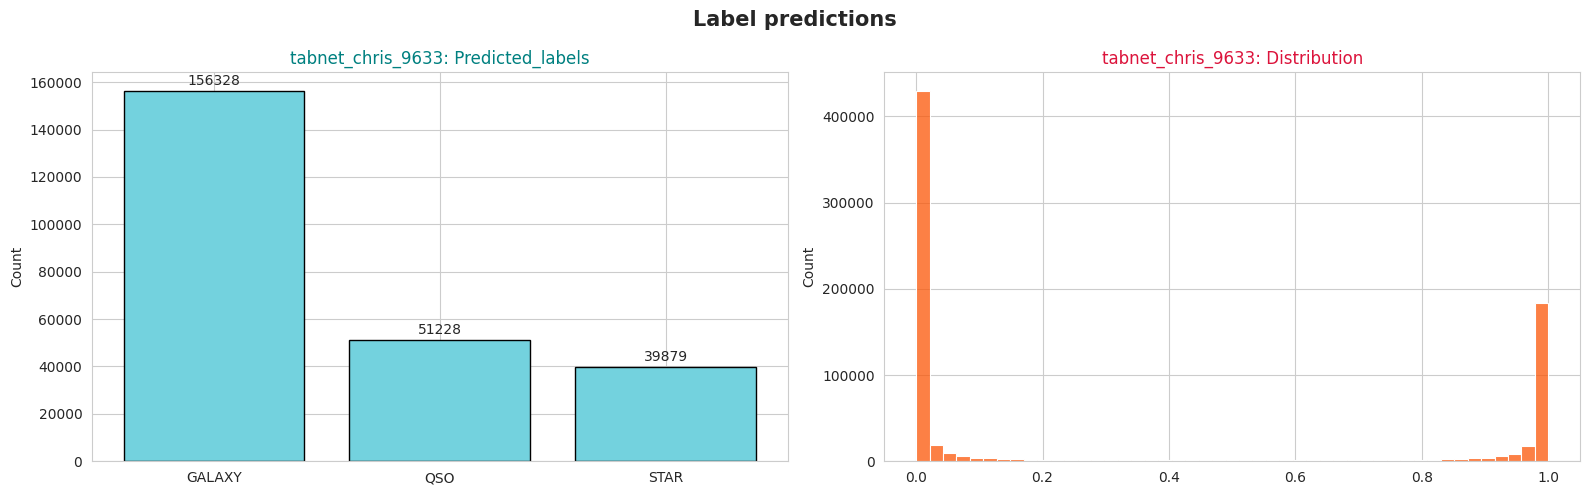

In [20]:
## -- Distribution plots --
counts = [np.sum(test_labels == _) for _ in range(len(np.unique(test_labels)))]

fig, axs = plt.subplots(1, 2, figsize=(16, 5))
axs[0].bar([*mapping.keys()], counts, color="#73D2DE", edgecolor="k")
axs[0].set_title(f"{n}: Predicted_labels", color="teal")
axs[0].set_ylabel("Count")

for i, c in enumerate(counts):
    axs[0].text(i, c+2500, str(c), ha="center", fontsize=10)

sns.histplot(test_preds.ravel(), ax=axs[1], color="#FB5607")
axs[1].set_title(f"{n}: Distribution", color="crimson")

plt.suptitle("Label predictions", fontsize=15, fontweight="semibold")
plt.tight_layout()
plt.show()

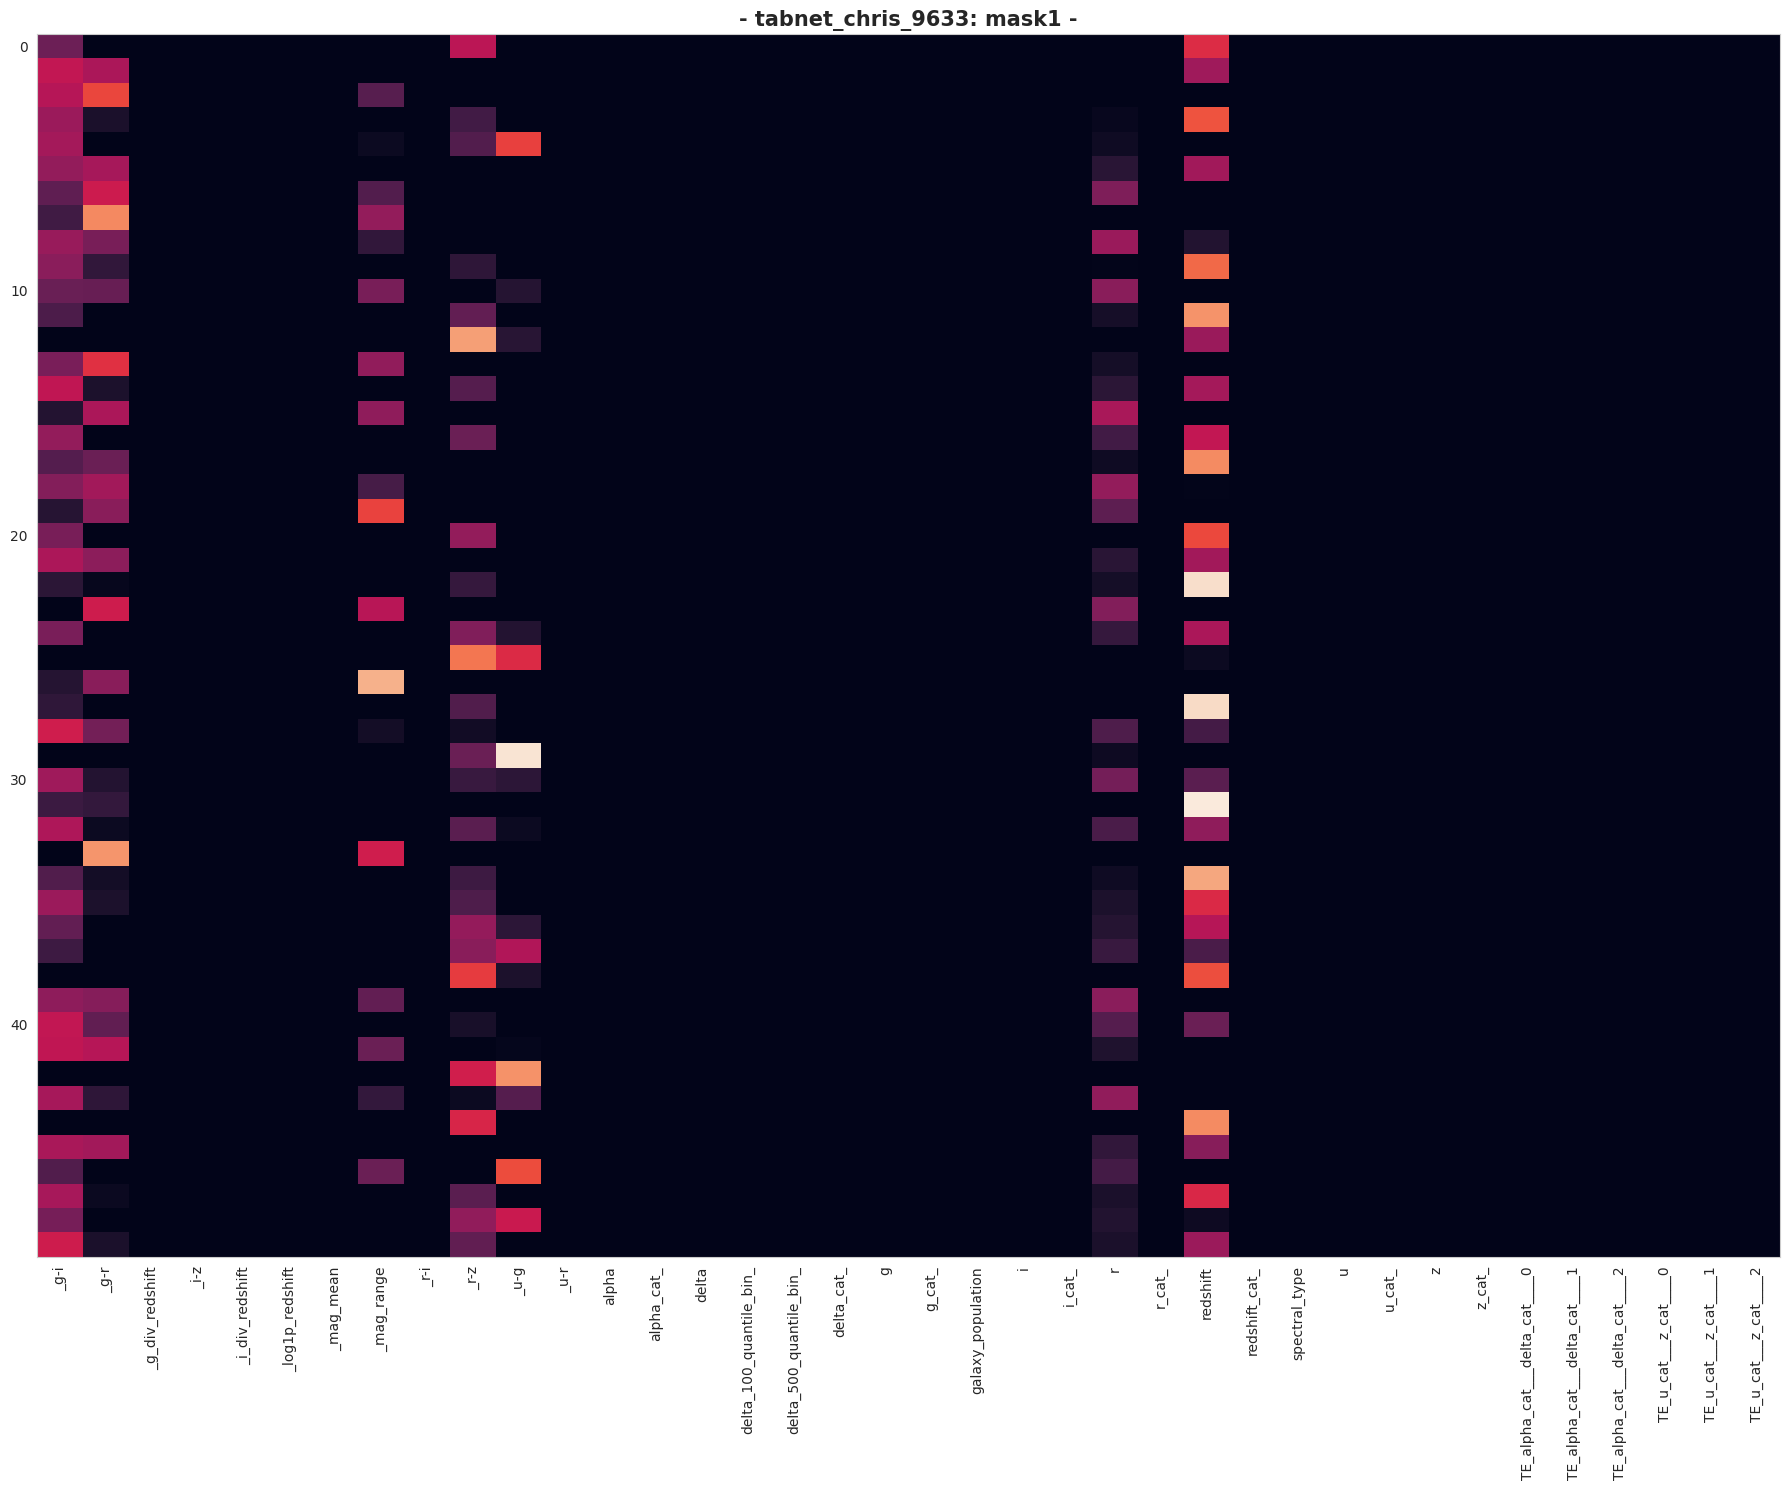

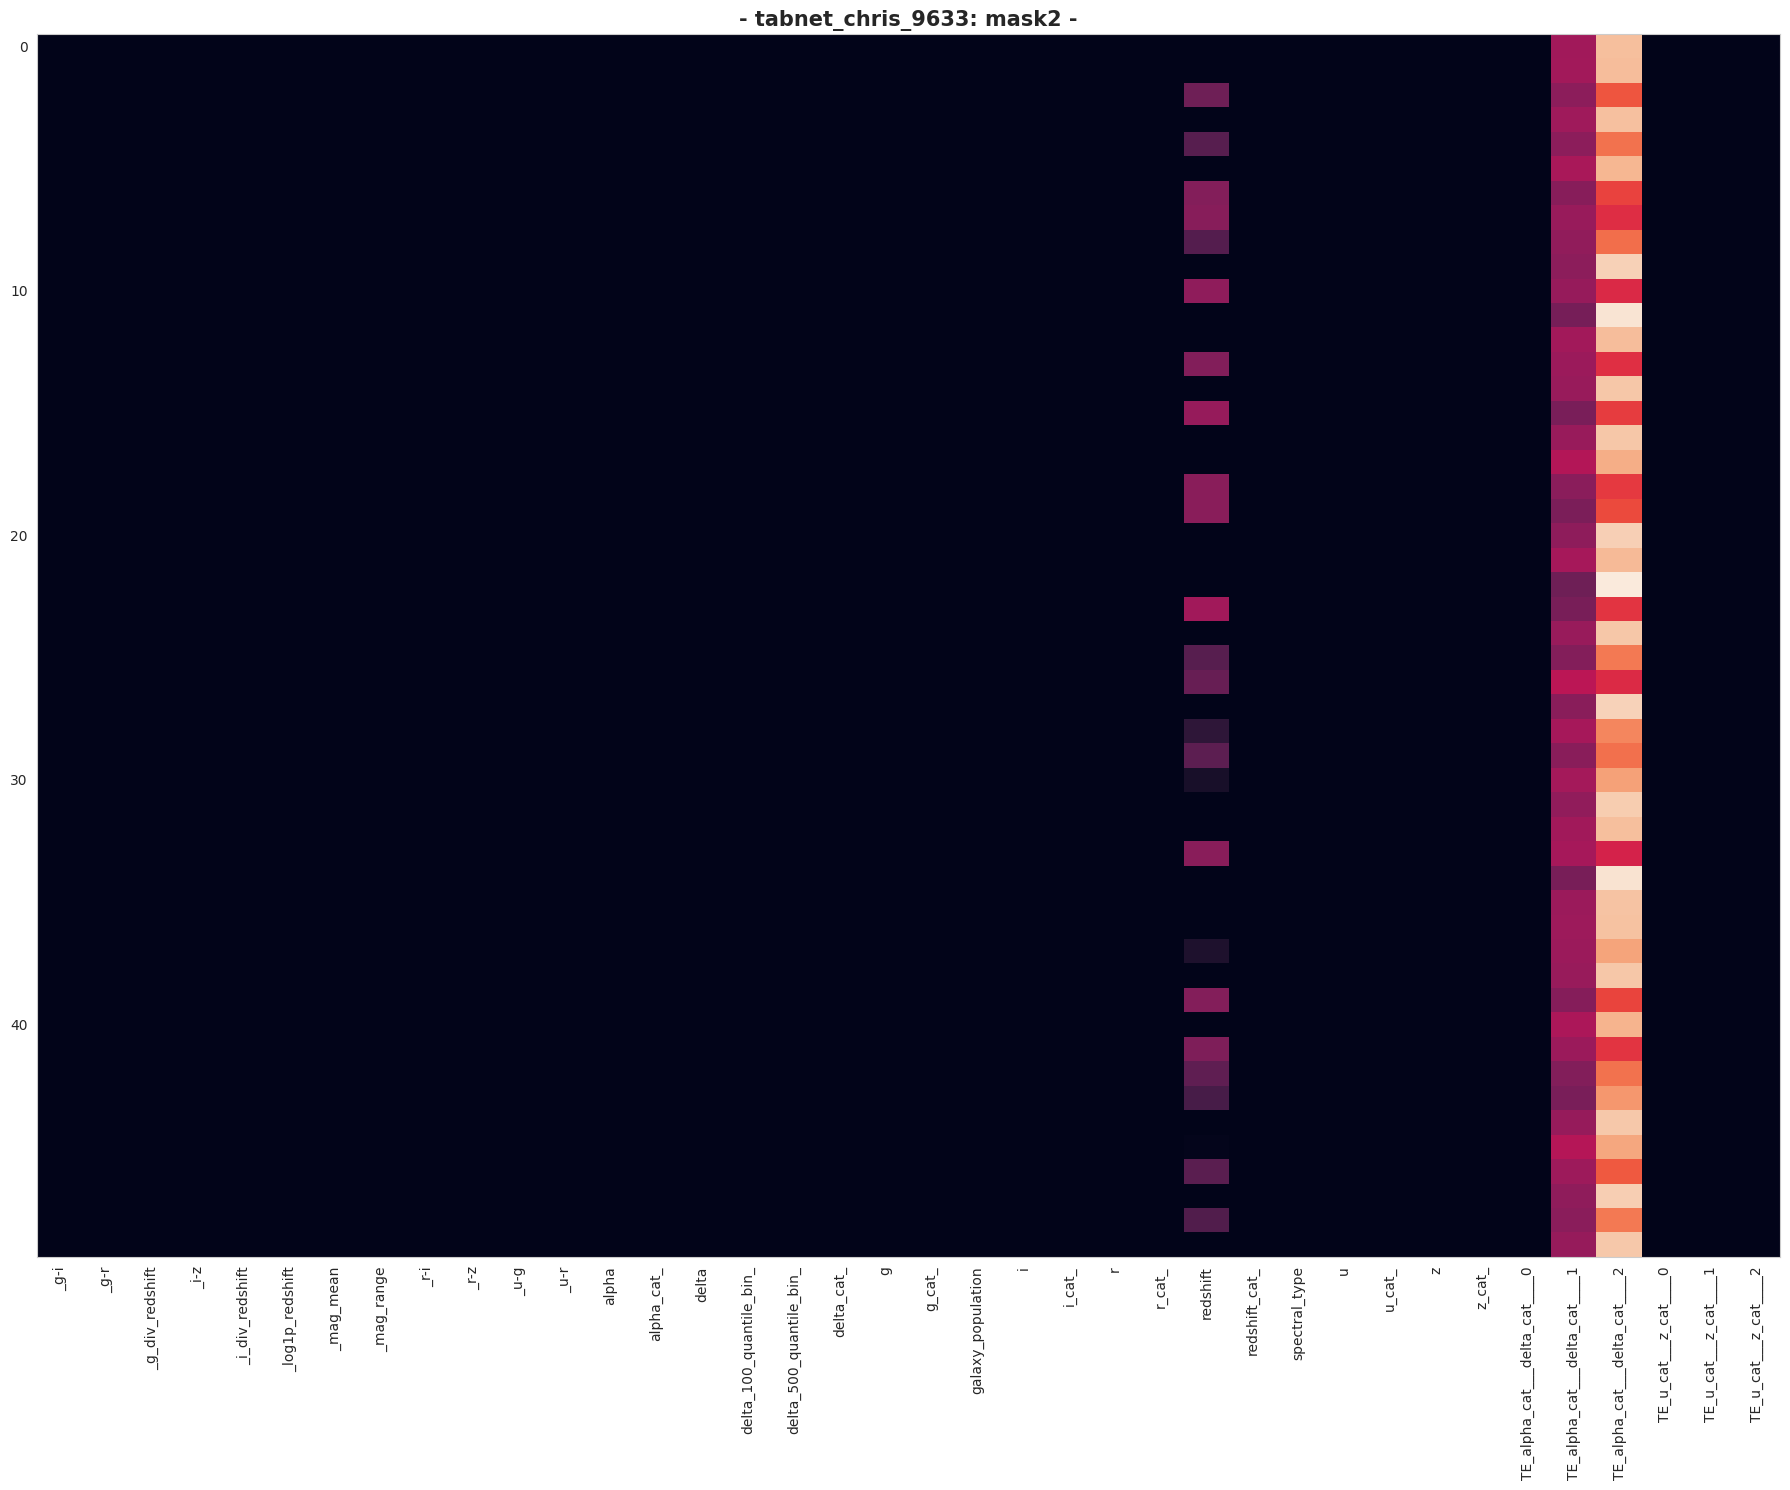

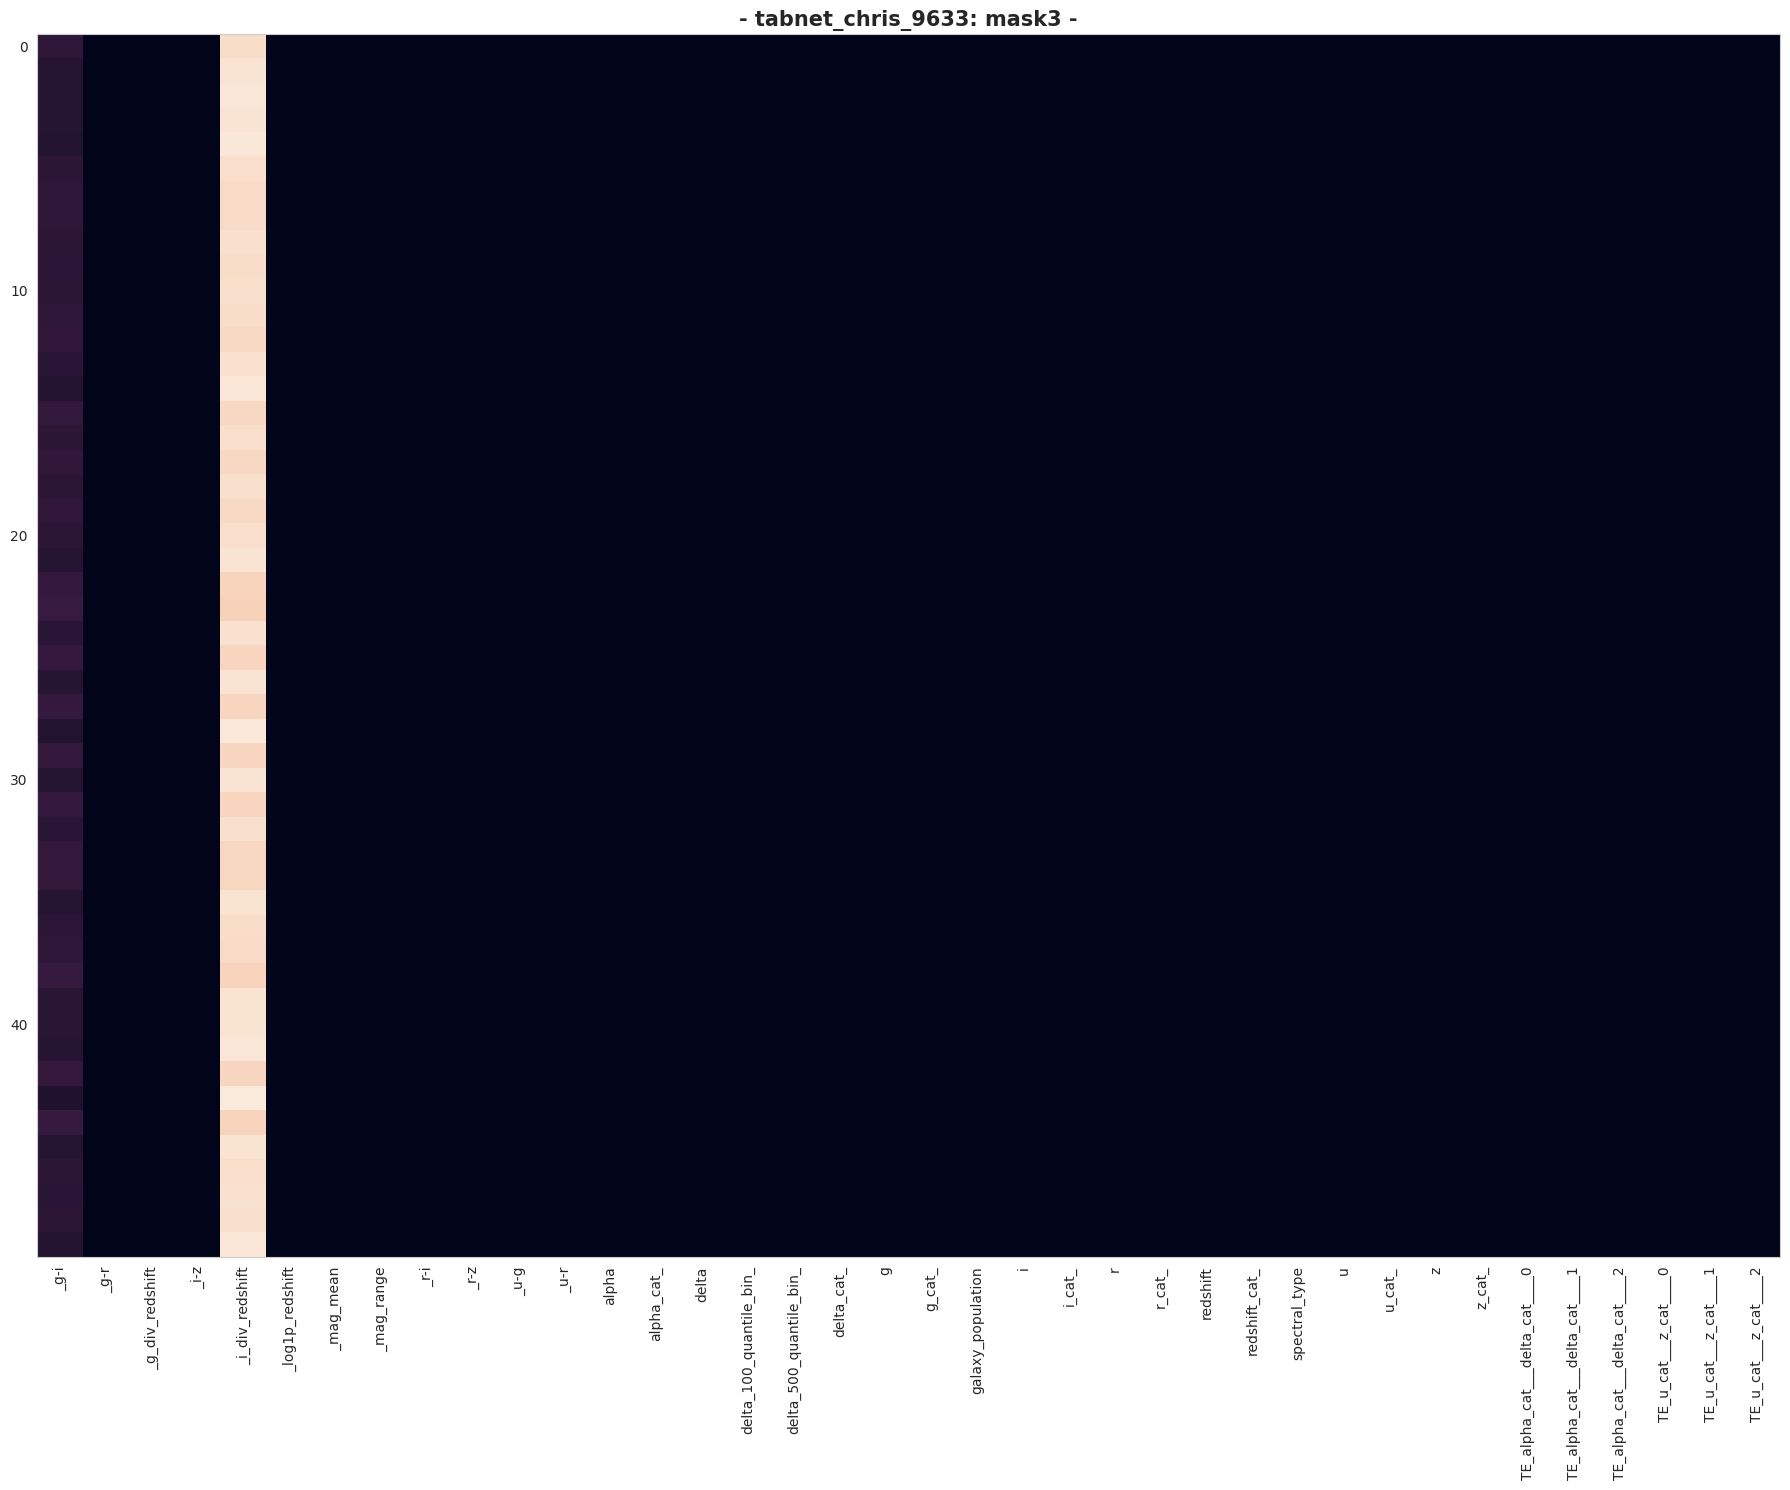

In [21]:
## -- Model feature importances --
explain_matrix, masks = model.explain(X_valid.to_numpy())

for i in range(3):
    fig, ax = plt.subplots(1, 1, figsize=(18, 15))
    ax.imshow(masks[i][:50], aspect='auto')
    ax.set_title(f"- {n}: mask{i+1} -", size=15, weight='semibold')
    ax.set_xticks(range(len(X_valid.columns)), X_valid.columns)
    ax.tick_params('x', rotation=90)
    ax.grid()
    plt.tight_layout()
    plt.show()
    print()

In [22]:
# !rm -r /kaggle/working